# 10 — Iran-conflict event study

**Onderzoekshypothese**: sinds de Iran-oorlog op 28 februari 2026 gebruikt Donald
Trump zijn Truth Social account doelbewust om de olieprijs te beïnvloeden.

**Aanpak**: event-study op intraday WTI, S&P 500 en XLE (Energy Sector ETF) rond
Trump's Iran-gerelateerde posts. Vergelijking met (a) controle-posts in dezelfde
periode en (b) baseline volatiliteit zonder posts.

**Data sources:**
- `data/raw/posts_live.parquet` — Trump posts vanaf 2026-02-28 (via trumpstruth.org RSS)
- `data/raw/trump_truth_archive.csv` — historische posts t/m 2026-04-23 (Kaggle)
- yfinance — WTI (`CL=F`), S&P 500 (`SPY`), Energy sector ETF (`XLE`)

**Plan:**
1. Combineer live + archive posts naar één tijdreeks.
2. Filter Iran-gerelateerde posts met keyword-lijst.
3. Download intraday + daily marktdata sinds conflictstart.
4. Event-study: voor elke Iran-post, prijsbeweging in [t-1h, t+1h, t+4h, t+24h].
5. Aggregeer + vergelijk met controle-posts.
6. Anchor events: 5 zelf-gekozen ankermomenten markeren op timeline.
7. Robustheidscheck: drop Hormuz-cluster en re-test.
8. Classificeer Iran-posts met onze eigen sentiment + toxicity models (notebook 08/09).
9. Identifeer top-10 meest impactvolle posts voor scriptie-narratief.

**Gebruik**: *Restart Kernel and Run All Cells*. De cellen zijn nu sequentieel
geordend en hebben elkaars variabelen nodig — niet individueel uitvoeren tenzij
je weet dat alle voorgaande cellen al gedraaid hebben.


In [1]:
%load_ext autoreload
%autoreload 2

import sys
import warnings
from datetime import date, datetime, timedelta
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent))

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import yfinance as yf
from scipy import stats

sns.set_theme(style="whitegrid", context="notebook")
warnings.filterwarnings("ignore")

CONFLICT_START = pd.Timestamp("2026-02-28", tz="UTC")
TODAY = pd.Timestamp.now(tz="UTC").normalize()
print(f"Conflict period: {CONFLICT_START.date()} → {TODAY.date()}  ({(TODAY - CONFLICT_START).days} dagen)")

Conflict period: 2026-02-28 → 2026-06-02  (94 dagen)


## 1. Load + combineer posts

Live posts (vanaf 28 feb 2026) + Kaggle archive (tot 23 apr 2026) → één DataFrame.


In [2]:
# Live scraped posts (run eerst `python -m src.data.scrape_trumpstruth_rss --start 2026-02-28`)
live_path = Path("../data/raw/posts_live.parquet")
if not live_path.exists():
    raise FileNotFoundError(
        "Run eerst de scraper:\n"
        "  python -m src.data.scrape_trumpstruth_rss --start 2026-02-28"
    )
live = pd.read_parquet(live_path)
live["timestamp_utc"] = pd.to_datetime(live["timestamp_utc"], utc=True)
print(f"Live posts: {len(live):,}  |  {live['timestamp_utc'].min()} → {live['timestamp_utc'].max()}")

# Optioneel: archive voor extra coverage (post_ids matchen niet noodzakelijk met live)
archive_path = Path("../data/raw/trump_truth_archive.csv")
if archive_path.exists():
    archive = pd.read_csv(archive_path, low_memory=False)
    archive["timestamp_utc"] = pd.to_datetime(archive["created_at"], utc=True, format="ISO8601")
    archive = archive[archive["timestamp_utc"] >= CONFLICT_START].dropna(subset=["text"])
    archive = archive[["id", "timestamp_utc", "text", "url"]].rename(columns={"id": "post_id"})
    archive["post_id"] = archive["post_id"].astype(str)
    print(f"Archive (vanaf 28 feb): {len(archive):,} posts")
else:
    archive = pd.DataFrame()

# Combineer + dedupe
combined = pd.concat([live, archive], ignore_index=True, sort=False)
combined["post_id"] = combined["post_id"].astype(str)
combined = combined.drop_duplicates(subset="post_id", keep="first")
combined = combined[combined["timestamp_utc"] >= CONFLICT_START].sort_values("timestamp_utc").reset_index(drop=True)
print(f"\nTotal unique posts since conflict start: {len(combined):,}")

Live posts: 363  |  2026-03-24 14:46:45+00:00 → 2026-06-02 11:19:52+00:00
Archive (vanaf 28 feb): 730 posts

Total unique posts since conflict start: 1,093


## 2. Filter Iran-gerelateerde posts

Keyword-lijst is breed gehouden — review de output handmatig en pas aan als nodig.


In [3]:
IRAN_KEYWORDS = [
    # Iran-specifiek
    "iran", "iranian", "tehran", "ayatollah", "khamenei", "raisi", "pezeshkian",
    "revolutionary guard", "irgc",
    # Geopolitiek
    "hormuz", "strait of hormuz", "persian gulf",
    "israel", "israeli", "netanyahu", "idf", "tel aviv",
    "houthi", "yemen", "hezbollah", "lebanon",
    # Energiebeleid
    "opec", "saudi", "saudi arabia", "riyadh", "mbs",
    "oil", "crude", "petroleum", "barrel", "gasoline",
    "drill", "drilling", "pipeline", "energy independence",
    # Militaire actie
    "strike", "airstrike", "missile", "nuclear",
    "sanctions", "embargo", "tariff",
]

# Case-insensitive substring match
pattern = "|".join(IRAN_KEYWORDS)
mask_iran = combined["text"].str.lower().str.contains(pattern, na=False, regex=True)

iran_posts = combined[mask_iran].copy()
control_posts = combined[~mask_iran].copy()

print(f"Iran-related posts:  {len(iran_posts):,}  ({len(iran_posts)/len(combined)*100:.1f}%)")
print(f"Control posts:       {len(control_posts):,}")
print(f"\nFirst 5 Iran posts:")
for _, row in iran_posts.head(5).iterrows():
    print(f"  [{row['timestamp_utc']}]  {row['text'][:130]}")

Iran-related posts:  264  (24.2%)
Control posts:       829

First 5 Iran posts:
  [2026-02-28 01:36:37.942000+00:00]  Dr. Dawn Buckingham is the strong and highly popular Land Commissioner for Texas, a place I love and WON BIG three times, includin
  [2026-02-28 09:35:09.244000+00:00]  Iran tried to interfere in 2020, 2024 elections to stop Trump, and now faces renewed war with United States:https://justthenews.co
  [2026-02-28 21:37:32.278000+00:00]  Khamenei, one of the most evil people in History, is dead. This is not only Justice for the people of Iran, but for all Great Amer
  [2026-03-01 05:25:12+00:00]  Iran just stated that they are going to hit very hard today, harder than they have ever hit before. THEY BETTER NOT DO THAT, HOWEV
  [2026-03-01 12:40:35.003000+00:00]  Michael Goodwin: The death of Ayatollah Khamenei instantly makes the world a better place: https://nypost.com/2026/02/28/opinion/t


## 3. Download marktdata sinds conflictstart

Drie tickers, 2 granulariteiten:
- **Daily** (full window 28 feb → vandaag) voor de overall picture.
- **Hourly** (laatste 60 dagen via yfinance limiet) voor intraday event-study.


In [4]:
TICKERS = {
    "WTI": "CL=F",
    "SPY": "SPY",
    "XLE": "XLE",
}

def download_market(ticker_alias: str, ticker_symbol: str, start: pd.Timestamp, interval: str = "1d") -> pd.DataFrame:
    df = yf.download(ticker_symbol, start=start.date(), interval=interval, progress=False, auto_adjust=False)
    if df.empty:
        return df
    df.columns = [c.lower() for c in df.columns.get_level_values(0)] if df.columns.nlevels > 1 else [c.lower() for c in df.columns]
    df = df.reset_index().rename(columns={df.index.name or df.columns[0]: "datetime"})
    df.columns = [c.lower() for c in df.columns]
    if "datetime" not in df.columns:
        df = df.rename(columns={"date": "datetime"})
    df["datetime"] = pd.to_datetime(df["datetime"], utc=True).dt.tz_convert("UTC")
    df["ticker"] = ticker_alias
    df["return"] = np.log(df["close"] / df["close"].shift(1))
    return df


# Daily
daily_frames = []
for alias, sym in TICKERS.items():
    print(f"Downloading {alias} daily…")
    daily_frames.append(download_market(alias, sym, CONFLICT_START, interval="1d"))
daily = pd.concat(daily_frames, ignore_index=True)

# Hourly (alleen voor laatste ~60 dagen)
hourly_start = max(CONFLICT_START, pd.Timestamp.now(tz="UTC") - timedelta(days=59))
hourly_frames = []
for alias, sym in TICKERS.items():
    print(f"Downloading {alias} hourly…")
    hourly_frames.append(download_market(alias, sym, hourly_start, interval="1h"))
hourly = pd.concat(hourly_frames, ignore_index=True)

print(f"\nDaily: {len(daily):,} rows ({daily['ticker'].value_counts().to_dict()})")
print(f"Hourly: {len(hourly):,} rows from {hourly_start.date()}")


Daily: 193 rows ({'WTI': 65, 'SPY': 64, 'XLE': 64})
Hourly: 1,479 rows from 2026-04-04


## 4. Anchor events

**Vul hieronder de 5 ankerevenementen in met echte data en korte beschrijving.**
De 5 voorgesteld door Claude zijn placeholders — pas aan naar wat jij weet over
het conflict. Het Strait of Hormuz event (11-12 april) is al ingevuld op basis
van eerdere bevindingen.


In [5]:
ANCHOR_EVENTS = [
    # (datum, label, korte beschrijving)
    ("2026-02-28", "Conflict start",       "Begin van de Iran-oorlog."),
    ("2026-03-XX", "Eerste escalatie",     "VUL IN: eerste grote escalatie-moment."),
    ("2026-04-11", "Hormuz blockade",      "Trump kondigt naval blockade van Strait of Hormuz aan."),
    ("2026-04-XX", "OPEC respons",         "VUL IN: OPEC emergency meeting of belangrijke productie-aankondiging."),
    ("2026-05-XX", "Recent moment",        "VUL IN: meest recente ankermoment voor je verdediging."),
]

anchor_df = pd.DataFrame(ANCHOR_EVENTS, columns=["date", "label", "description"])
anchor_df["date"] = pd.to_datetime(anchor_df["date"], utc=True, errors="coerce")
print(anchor_df.to_string(index=False))

                     date            label                                                           description
2026-02-28 00:00:00+00:00   Conflict start                                             Begin van de Iran-oorlog.
                      NaT Eerste escalatie                                VUL IN: eerste grote escalatie-moment.
2026-04-11 00:00:00+00:00  Hormuz blockade                Trump kondigt naval blockade van Strait of Hormuz aan.
                      NaT     OPEC respons VUL IN: OPEC emergency meeting of belangrijke productie-aankondiging.
                      NaT    Recent moment                VUL IN: meest recente ankermoment voor je verdediging.


## 5. Timeline: marktprijzen + post density + ankers


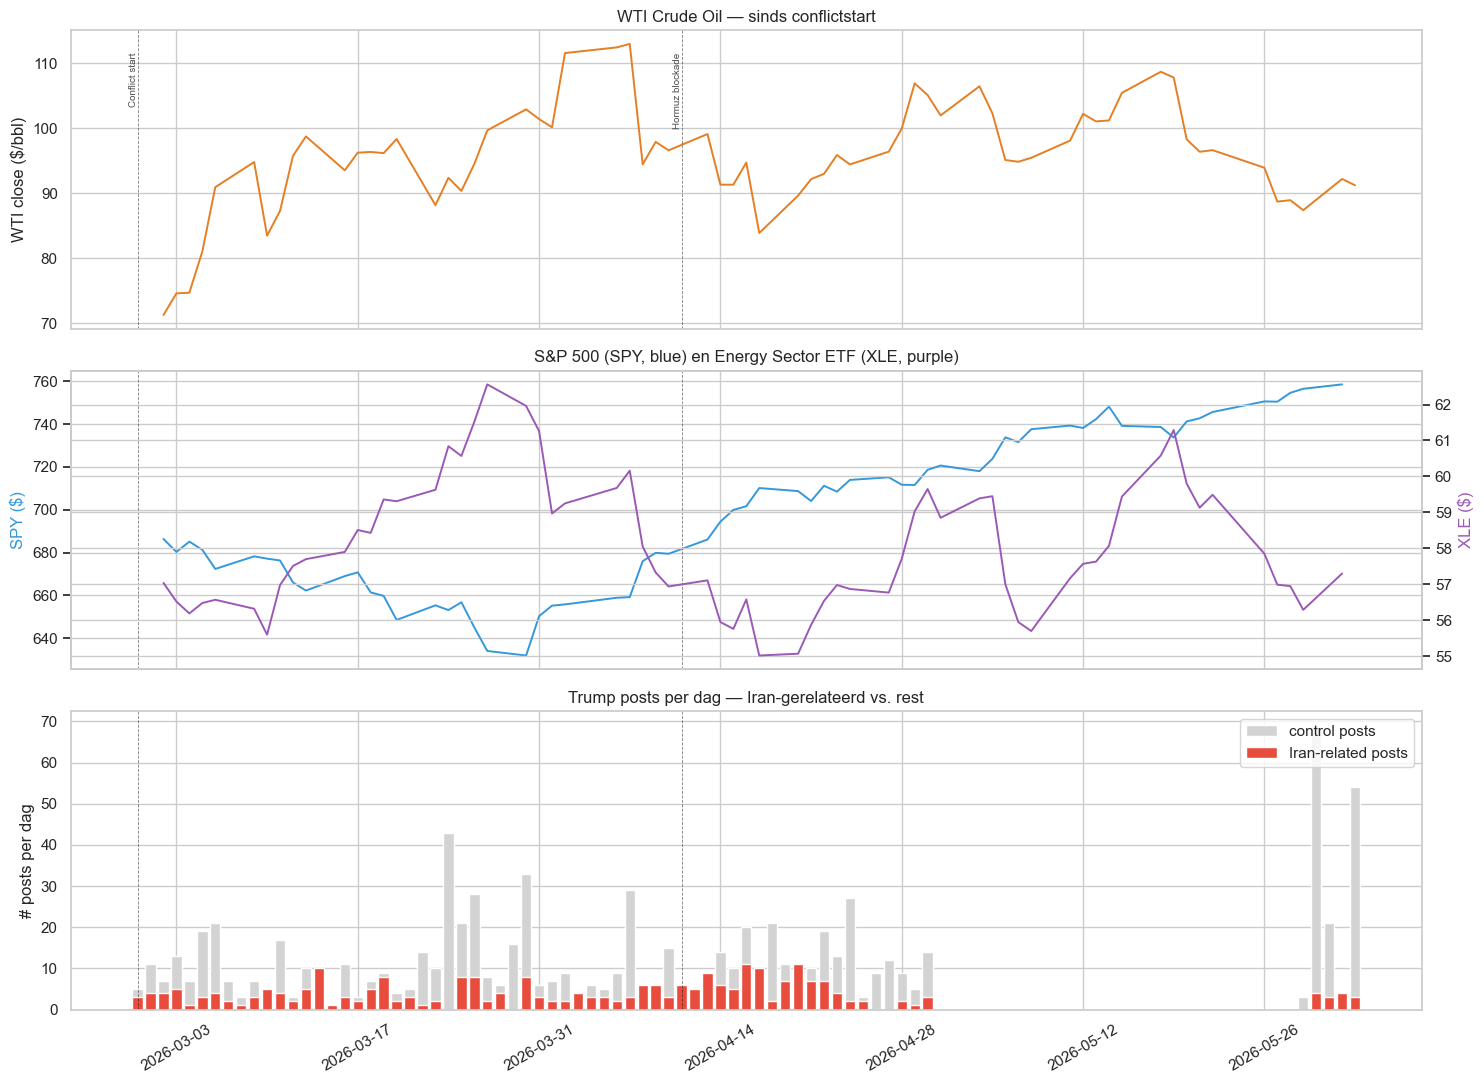

In [6]:
fig, axes = plt.subplots(3, 1, figsize=(15, 11), sharex=True)

# Top: WTI olie prijs (daily close)
wti = daily[daily["ticker"] == "WTI"].sort_values("datetime")
axes[0].plot(wti["datetime"], wti["close"], color="#e67e22", linewidth=1.4)
axes[0].set_ylabel("WTI close ($/bbl)")
axes[0].set_title("WTI Crude Oil — sinds conflictstart")

# Middle: SPY (S&P 500) + XLE (energy)
spy = daily[daily["ticker"] == "SPY"].sort_values("datetime")
xle = daily[daily["ticker"] == "XLE"].sort_values("datetime")
ax_spy = axes[1]
ax_xle = ax_spy.twinx()
ax_spy.plot(spy["datetime"], spy["close"], color="#3498db", linewidth=1.4, label="SPY")
ax_xle.plot(xle["datetime"], xle["close"], color="#9b59b6", linewidth=1.4, label="XLE")
ax_spy.set_ylabel("SPY ($)", color="#3498db")
ax_xle.set_ylabel("XLE ($)", color="#9b59b6")
ax_spy.set_title("S&P 500 (SPY, blue) en Energy Sector ETF (XLE, purple)")

# Bottom: Post density per dag (Iran vs control)
iran_daily = iran_posts.set_index("timestamp_utc").resample("D").size()
control_daily = control_posts.set_index("timestamp_utc").resample("D").size()
axes[2].bar(control_daily.index, control_daily.values, color="lightgray", width=0.8, label="control posts")
axes[2].bar(iran_daily.index, iran_daily.values, color="#e74c3c", width=0.8, label="Iran-related posts")
axes[2].set_ylabel("# posts per dag")
axes[2].set_title("Trump posts per dag — Iran-gerelateerd vs. rest")
axes[2].legend(loc="upper right")

# Anchor lines op alle subplots
for d, label, _ in ANCHOR_EVENTS:
    d = pd.to_datetime(d, utc=True, errors="coerce")
    if pd.isna(d):
        continue
    for ax in axes:
        ax.axvline(d, color="black", linewidth=0.6, alpha=0.5, linestyle="--")
    axes[0].annotate(label, xy=(d, axes[0].get_ylim()[1]*0.97),
                     xytext=(d, axes[0].get_ylim()[1]*0.97), rotation=90,
                     fontsize=7, ha="right", va="top", color="black", alpha=0.7)

axes[-1].xaxis.set_major_locator(mdates.WeekdayLocator(interval=2))
axes[-1].xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m-%d"))
plt.setp(axes[-1].get_xticklabels(), rotation=30)
plt.tight_layout()
plt.show()

## 6. Per-post event study (intraday)

Voor elke Iran-post, kijk naar WTI/SPY/XLE prijs t.o.v. **t-1h, t+1h, t+4h, t+24h**.
Hourly data dekt alleen de laatste ~60 dagen, dus alleen recente posts.


In [7]:
def compute_event_returns(post_time: pd.Timestamp, market_df: pd.DataFrame,
                            windows: list = [-1, 1, 4, 24]) -> dict:
    """Voor één post, return log-returns voor de gegeven windows (uren)."""
    out = {}
    pre = market_df[market_df["datetime"] <= post_time]
    if pre.empty:
        return {f"ret_{w}h": np.nan for w in windows}
    p0 = pre.iloc[-1]["close"]
    for w in windows:
        target_time = post_time + pd.Timedelta(hours=w)
        if w < 0:
            pre_w = market_df[market_df["datetime"] <= target_time]
            if pre_w.empty:
                out[f"ret_{w}h"] = np.nan
                continue
            p1 = pre_w.iloc[-1]["close"]
            out[f"ret_{w}h"] = float(np.log(p0 / p1))
        else:
            post = market_df[market_df["datetime"] >= target_time]
            if post.empty:
                out[f"ret_{w}h"] = np.nan
                continue
            p1 = post.iloc[0]["close"]
            out[f"ret_{w}h"] = float(np.log(p1 / p0))
    return out


# Alleen voor posts in het hourly data window
recent_iran = iran_posts[iran_posts["timestamp_utc"] >= hourly_start].copy()
print(f"Iran posts in hourly window: {len(recent_iran)}")

results_rows = []
for _, row in recent_iran.iterrows():
    rec = {"post_id": row["post_id"], "timestamp_utc": row["timestamp_utc"],
            "text": row["text"]}
    for alias in TICKERS:
        market_t = hourly[hourly["ticker"] == alias].sort_values("datetime")
        rets = compute_event_returns(row["timestamp_utc"], market_t)
        for k, v in rets.items():
            rec[f"{alias}_{k}"] = v
    results_rows.append(rec)

event_df = pd.DataFrame(results_rows)
print(f"\nEvent study: {len(event_df)} Iran posts with intraday returns")
print(event_df.filter(like="WTI_ret").describe().round(5))

Iran posts in hourly window: 140

Event study: 140 Iran posts with intraday returns
       WTI_ret_-1h  WTI_ret_1h  WTI_ret_4h  WTI_ret_24h
count    134.00000   134.00000   134.00000    128.00000
mean      -0.00325     0.01353     0.01577      0.01931
std        0.01239     0.02989     0.03133      0.05273
min       -0.11067    -0.02531    -0.03999     -0.21026
25%       -0.00641    -0.00545    -0.00535     -0.01063
50%        0.00000     0.00317     0.00554      0.02726
75%        0.00108     0.01698     0.02521      0.05912
max        0.01851     0.09002     0.09002      0.09164


## 7. Aggregaat-effect: Iran posts vs. control posts


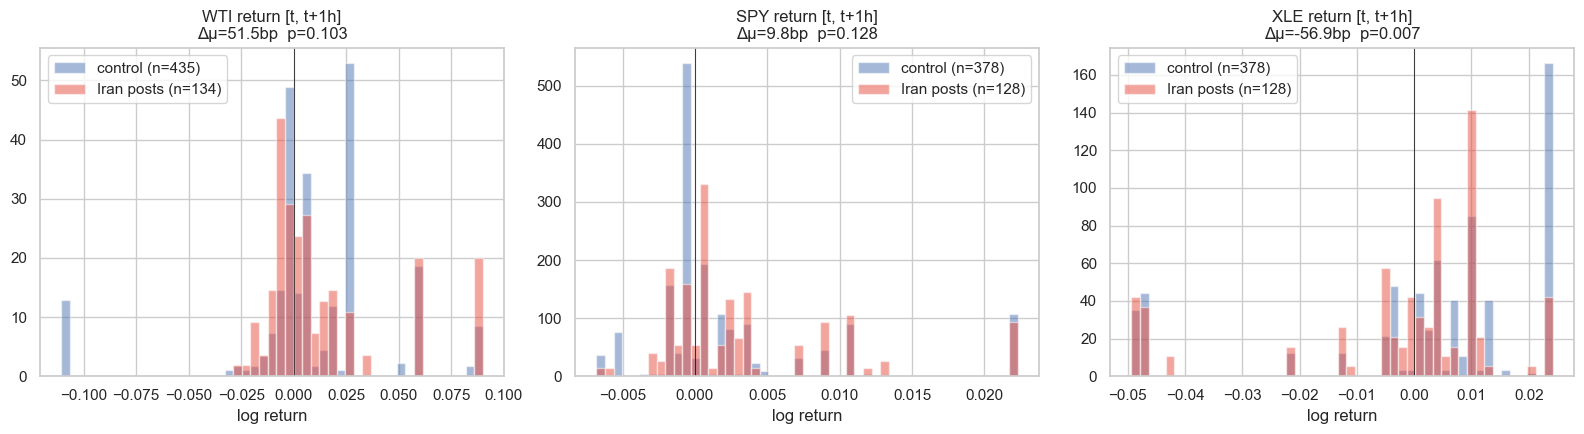

In [8]:
# Controle-groep: random sample van non-Iran posts in zelfde window
n_control = min(500, len(control_posts[control_posts["timestamp_utc"] >= hourly_start]))
control_sample = control_posts[control_posts["timestamp_utc"] >= hourly_start].sample(
    n=n_control, random_state=42
)

control_rows = []
for _, row in control_sample.iterrows():
    rec = {"post_id": row["post_id"], "timestamp_utc": row["timestamp_utc"]}
    for alias in TICKERS:
        market_t = hourly[hourly["ticker"] == alias].sort_values("datetime")
        rets = compute_event_returns(row["timestamp_utc"], market_t)
        for k, v in rets.items():
            rec[f"{alias}_{k}"] = v
    control_rows.append(rec)
control_df = pd.DataFrame(control_rows)

# Compare distributions
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
for ax, alias in zip(axes, TICKERS):
    col = f"{alias}_ret_1h"
    iran_vals = event_df[col].dropna()
    ctrl_vals = control_df[col].dropna()

    bins = np.linspace(
        np.percentile(np.concatenate([iran_vals, ctrl_vals]), 1),
        np.percentile(np.concatenate([iran_vals, ctrl_vals]), 99),
        50,
    )
    ax.hist(ctrl_vals, bins=bins, alpha=0.5, density=True, label=f"control (n={len(ctrl_vals)})")
    ax.hist(iran_vals, bins=bins, alpha=0.5, density=True, label=f"Iran posts (n={len(iran_vals)})", color="#e74c3c")
    ax.axvline(0, color="black", linewidth=0.5)
    t_stat, p_val = stats.ttest_ind(iran_vals, ctrl_vals, equal_var=False)
    ax.set_title(f"{alias} return [t, t+1h]\nΔμ={1e4*(iran_vals.mean()-ctrl_vals.mean()):.1f}bp  p={p_val:.3f}")
    ax.set_xlabel("log return")
    ax.legend()
plt.tight_layout()
plt.show()

In [9]:
# Numeriek: t-test per ticker × window
test_rows = []
for alias in TICKERS:
    for w in [-1, 1, 4, 24]:
        col = f"{alias}_ret_{w}h"
        iran_vals = event_df[col].dropna()
        ctrl_vals = control_df[col].dropna()
        if len(iran_vals) < 10 or len(ctrl_vals) < 10:
            continue
        t_stat, p_val = stats.ttest_ind(iran_vals, ctrl_vals, equal_var=False)
        test_rows.append({
            "ticker": alias, "window": f"{w}h",
            "n_iran": len(iran_vals), "n_ctrl": len(ctrl_vals),
            "mean_iran_bp": iran_vals.mean()*1e4,
            "mean_ctrl_bp": ctrl_vals.mean()*1e4,
            "diff_bp": (iran_vals.mean() - ctrl_vals.mean())*1e4,
            "t_stat": t_stat,
            "p_value": p_val,
        })
tests = pd.DataFrame(test_rows).round(3)
print("\n=== T-test: Iran posts vs control posts (alle data) ===")
print(tests.to_string(index=False))


=== T-test: Iran posts vs control posts (alle data) ===
ticker window  n_iran  n_ctrl  mean_iran_bp  mean_ctrl_bp  diff_bp  t_stat  p_value
   WTI    -1h     134     436       -32.507       -20.728  -11.779  -1.037    0.301
   WTI     1h     134     435       135.304        83.764   51.540   1.635    0.103
   WTI     4h     134     435       157.652        78.114   79.538   2.357    0.019
   WTI    24h     128     381       193.104        80.945  112.159   2.051    0.041
   SPY    -1h     132     433         6.563         2.649    3.914   1.814    0.072
   SPY     1h     128     378        31.824        21.980    9.844   1.526    0.128
   SPY     4h     126     378        36.019        25.422   10.598   1.589    0.113
   SPY    24h     124     375        54.977        47.011    7.966   0.981    0.328
   XLE    -1h     132     433       -17.116         0.553  -17.669  -2.084    0.039
   XLE     1h     128     378       -33.054        23.820  -56.874  -2.704    0.007
   XLE     4h     1

## 7b. Robustheidscheck: drop Hormuz-cluster (11-12 april)

Een groot deel van het top-10 impact komt van één 24-uurs venster rond de
Strait of Hormuz blockade aankondiging. Cruciale check: blijft het effect
overeind als we deze cluster verwijderen?

- Δμ blijft groot en p<0.05 → effect is breed fenomeen, niet één event
- Δμ daalt fors maar p<0.05 → kleiner maar reëel patroon over hele periode
- Δμ dicht bij 0, p>0.05 → het hele effect kwam van die ene cluster


In [10]:
# Robustness: drop top-impact cluster (11-12 april) en re-test
mask_cluster = event_df["timestamp_utc"].dt.date.isin([
    pd.Timestamp("2026-04-11").date(),
    pd.Timestamp("2026-04-12").date(),
])
event_no_cluster = event_df[~mask_cluster]
print(f"Iran posts after dropping Hormuz cluster: {len(event_no_cluster)} (was {len(event_df)})")
print()

robust_rows = []
for alias in TICKERS:
    for w in [-1, 1, 4, 24]:
        col = f"{alias}_ret_{w}h"
        iran_no = event_no_cluster[col].dropna()
        ctrl = control_df[col].dropna()
        if len(iran_no) < 10 or len(ctrl) < 10:
            continue
        t_stat, p_val = stats.ttest_ind(iran_no, ctrl, equal_var=False)
        robust_rows.append({
            "ticker": alias, "window": f"{w}h",
            "n_iran_no_cluster": len(iran_no),
            "n_ctrl": len(ctrl),
            "mean_iran_bp": iran_no.mean()*1e4,
            "mean_ctrl_bp": ctrl.mean()*1e4,
            "diff_bp": (iran_no.mean() - ctrl.mean())*1e4,
            "t_stat": t_stat,
            "p_value": p_val,
        })
robust_tests = pd.DataFrame(robust_rows).round(3)
print("=== T-test: Iran posts vs control (Hormuz cluster excluded) ===")
print(robust_tests.to_string(index=False))

Iran posts after dropping Hormuz cluster: 129 (was 140)

=== T-test: Iran posts vs control (Hormuz cluster excluded) ===
ticker window  n_iran_no_cluster  n_ctrl  mean_iran_bp  mean_ctrl_bp  diff_bp  t_stat  p_value
   WTI    -1h                123     436       -35.414       -20.728  -14.686  -1.200    0.232
   WTI     1h                123     435        66.903        83.764  -16.862  -0.661    0.509
   WTI     4h                123     435        91.249        78.114   13.135   0.454    0.650
   WTI    24h                117     381       139.866        80.945   58.922   1.058    0.291
   SPY    -1h                121     433         7.160         2.649    4.511   1.934    0.055
   SPY     1h                117     378        34.500        21.980   12.520   1.829    0.069
   SPY     4h                115     378        39.143        25.422   13.721   1.941    0.054
   SPY    24h                113     375        59.244        47.011   12.233   1.424    0.156
   XLE    -1h           

## 8. Top-10 meest impactvolle Iran posts

Sorteer op absolute WTI return [t, t+1h]. Dit zijn de posts waarvan het verhaal
in je scriptie waarschijnlijk komt.


In [11]:
event_df["WTI_abs_ret_1h"] = event_df["WTI_ret_1h"].abs()
top_impact = event_df.nlargest(10, "WTI_abs_ret_1h")

for _, row in top_impact.iterrows():
    direction = "↑" if row["WTI_ret_1h"] > 0 else "↓"
    print(f"\n[{row['timestamp_utc']}]  WTI {direction}{abs(row['WTI_ret_1h'])*100:.2f}%  "
          f"SPY {row['SPY_ret_1h']*100:+.2f}%  XLE {row['XLE_ret_1h']*100:+.2f}%")
    print(f"  {row['text'][:300]}")


[2026-04-11 11:30:41.036000+00:00]  WTI ↑9.00%  SPY +0.03%  XLE +0.45%
  Massive numbers of completely empty oil tankers, some of the largest anywhere in the World, are heading, right now, to the United States to load up with the best and "sweetest" oil (and gas!) anywhere in the World. We have more oil than the next two largest oil economies combined - and higher qualit

[2026-04-11 12:58:48.715000+00:00]  WTI ↑9.00%  SPY +0.03%  XLE +0.45%
  The Fake News Media has lost total credibility, not that they had any to begin with. Because of their massive Trump Derangement Syndrome (Sometimes referred to as TDS!), they love saying that Iran is "winning" when, in fact, everyone knows that they are LOSING, and LOSING BIG! Their Navy is gone, th

[2026-04-11 13:07:02.216000+00:00]  WTI ↑9.00%  SPY +0.03%  XLE +0.45%
  I am watching fertilizer prices CLOSELY during our FIGHT FOR FREEDOM in Iran. The United States will not accept PRICE GOUGING from the fertilizer monopoly! American Farmers, we

## 9. Sentiment + toxicity van Iran-posts

Gebruik onze eigen classifiers (notebook 08/09) om de Iran-posts te
karakteriseren. Verschilt hun sentiment/toxicity van non-Iran posts?


In [12]:
# Load eigen classifiers
try:
    sentiment_vec = joblib.load("../models/sentiment/vectorizer.joblib")
    sentiment_clf = joblib.load("../models/sentiment/logistic_l1.joblib")
    toxicity_vec = joblib.load("../models/toxicity/vectorizer.joblib")
    toxicity_clf = joblib.load("../models/toxicity/logistic_l1.joblib")
    CLASSIFIERS_AVAILABLE = True
except FileNotFoundError as e:
    print(f"Classifiers niet gevonden — run eerst notebook 08 en 09. {e}")
    CLASSIFIERS_AVAILABLE = False

if CLASSIFIERS_AVAILABLE:
    from src.data.preprocess import clean_text

    def score_posts(df_posts):
        cleaned = df_posts["text"].apply(clean_text)
        X_sent = sentiment_vec.transform(cleaned)
        X_tox = toxicity_vec.transform(cleaned)
        df = df_posts.copy()
        df["pred_sentiment"] = sentiment_clf.predict(X_sent)
        df["proba_high_tox"] = toxicity_clf.predict_proba(X_tox)[:, 1]
        return df

    iran_scored = score_posts(iran_posts)
    control_scored = score_posts(control_posts.sample(min(2000, len(control_posts)), random_state=42))

    print("Sentiment distributie (Iran vs Control):")
    sent_compare = pd.DataFrame({
        "iran": iran_scored["pred_sentiment"].value_counts(normalize=True).round(3),
        "control": control_scored["pred_sentiment"].value_counts(normalize=True).round(3),
    })
    print(sent_compare)
    print(f"\nMean toxicity probability:")
    print(f"  Iran posts:    {iran_scored['proba_high_tox'].mean():.3f}")
    print(f"  Control posts: {control_scored['proba_high_tox'].mean():.3f}")

    t_stat, p_val = stats.ttest_ind(iran_scored["proba_high_tox"],
                                      control_scored["proba_high_tox"], equal_var=False)
    print(f"  t-stat: {t_stat:.2f}  p-value: {p_val:.4g}")

Sentiment distributie (Iran vs Control):
                 iran  control
pred_sentiment                
negative        0.318    0.163
neutral         0.167    0.408
positive        0.515    0.429

Mean toxicity probability:
  Iran posts:    0.395
  Control posts: 0.368
  t-stat: 1.33  p-value: 0.1833


In [13]:
# Granger causality test (v2 — robuuste alignment)
from statsmodels.tsa.stattools import grangercausalitytests

# Begin met WTI hourly returns als base
wti_h = (
    hourly[hourly["ticker"] == "WTI"]
    .set_index("datetime")
    .sort_index()[["return"]]
    .rename(columns={"return": "wti_ret"})
)
print(f"WTI hourly observations: {len(wti_h)}")

# Voor elk WTI-uur: tel Iran-posts in dat uur (van begin-uur tot eind-uur)
def count_posts_in_hour(hour_ts):
    return ((iran_posts["timestamp_utc"] >= hour_ts) &
            (iran_posts["timestamp_utc"] < hour_ts + pd.Timedelta(hours=1))).sum()

wti_h["iran_posts"] = wti_h.index.to_series().apply(count_posts_in_hour)

# Drop NaNs in returns (eerste rij heeft geen return)
df_granger = wti_h.dropna()
print(f"Granger sample: {len(df_granger)} hourly observations")
print(f"Hours with ≥1 Iran post: {(df_granger['iran_posts'] > 0).sum()}")
print(f"Total Iran posts in window: {df_granger['iran_posts'].sum()}\n")

if len(df_granger) < 20:
    print("ERROR: te weinig observaties. Check of hourly data correct geladen is.")
else:
    # Test 1: doen Iran-posts WTI returns Granger-causeren?
    print("=== Test 1: Iran posts → WTI returns ===")
    print("(als p<0.05: past Iran posts helpen toekomstige WTI returns voorspellen)")
    result_1 = grangercausalitytests(df_granger[["wti_ret", "iran_posts"]], maxlag=4, verbose=False)
    for lag, r in result_1.items():
        print(f"  lag={lag}h:  F={r[0]['ssr_ftest'][0]:.3f}  p={r[0]['ssr_ftest'][1]:.4f}")

    print("\n=== Test 2: WTI returns → Iran posts (reverse) ===")
    print("(als p<0.05: past WTI returns helpen toekomstige Iran-posts voorspellen)")
    result_2 = grangercausalitytests(df_granger[["iran_posts", "wti_ret"]], maxlag=4, verbose=False)
    for lag, r in result_2.items():
        print(f"  lag={lag}h:  F={r[0]['ssr_ftest'][0]:.3f}  p={r[0]['ssr_ftest'][1]:.4f}")

WTI hourly observations: 919
Granger sample: 918 hourly observations
Hours with ≥1 Iran post: 70
Total Iran posts in window: 97

=== Test 1: Iran posts → WTI returns ===
(als p<0.05: past Iran posts helpen toekomstige WTI returns voorspellen)
  lag=1h:  F=0.039  p=0.8438
  lag=2h:  F=0.028  p=0.9724
  lag=3h:  F=0.059  p=0.9814
  lag=4h:  F=0.070  p=0.9911

=== Test 2: WTI returns → Iran posts (reverse) ===
(als p<0.05: past WTI returns helpen toekomstige Iran-posts voorspellen)
  lag=1h:  F=2.129  p=0.1449
  lag=2h:  F=6.508  p=0.0016
  lag=3h:  F=5.262  p=0.0013
  lag=4h:  F=4.320  p=0.0018


In [14]:
# Granger causality op 5-minuten resolutie (yfinance limiet)
from statsmodels.tsa.stattools import grangercausalitytests

# Download WTI 5-min data (max ~60 dagen via yfinance)
print("Downloading WTI 5-min data (60 days)…")
wti_5m_raw = yf.download("CL=F", period="60d", interval="5m", progress=False, auto_adjust=False)
if wti_5m_raw.columns.nlevels > 1:
    wti_5m_raw.columns = [c.lower() for c in wti_5m_raw.columns.get_level_values(0)]
else:
    wti_5m_raw.columns = [c.lower() for c in wti_5m_raw.columns]
wti_5m = wti_5m_raw.reset_index()
wti_5m.columns = [c.lower() for c in wti_5m.columns]
wti_5m["datetime"] = pd.to_datetime(wti_5m["datetime"], utc=True)
wti_5m = wti_5m.set_index("datetime").sort_index()
wti_5m["ret"] = np.log(wti_5m["close"] / wti_5m["close"].shift(1))

print(f"WTI 5m bars: {len(wti_5m):,}")
print(f"Period: {wti_5m.index.min()} → {wti_5m.index.max()}")

# Count Iran posts per 5m bar
start = wti_5m.index.min()
end = wti_5m.index.max()
iran_in_window = iran_posts[(iran_posts["timestamp_utc"] >= start) & (iran_posts["timestamp_utc"] <= end)].copy()
iran_in_window["bin_5m"] = iran_in_window["timestamp_utc"].dt.floor("5min")
post_counts = iran_in_window.groupby("bin_5m").size()
wti_5m["iran_posts"] = post_counts.reindex(wti_5m.index, fill_value=0)

df_5m = wti_5m[["ret", "iran_posts"]].dropna()
print(f"\n5-min sample: {len(df_5m):,} observations")
print(f"Bars met ≥1 Iran post: {(df_5m['iran_posts'] > 0).sum()}")
print(f"Total Iran posts in sample: {df_5m['iran_posts'].sum()}\n")

if len(df_5m) < 100:
    print("ERROR: te weinig observaties.")
else:
    lags = [1, 2, 3, 6, 12]   # = 5, 10, 15, 30, 60 minuten
    print("=== Test 1: Iran posts → WTI returns ===")
    print("(als p<0.05: post in T-X helpt return in T voorspellen)")
    result_1 = grangercausalitytests(df_5m[["ret", "iran_posts"]], maxlag=lags, verbose=False)
    for lag, r in result_1.items():
        mins = lag * 5
        print(f"  lag={lag} ({mins:>3d}min):  F={r[0]['ssr_ftest'][0]:6.3f}  p={r[0]['ssr_ftest'][1]:.4f}")

    print("\n=== Test 2: WTI returns → Iran posts (reverse) ===")
    result_2 = grangercausalitytests(df_5m[["iran_posts", "ret"]], maxlag=lags, verbose=False)
    for lag, r in result_2.items():
        mins = lag * 5
        print(f"  lag={lag} ({mins:>3d}min):  F={r[0]['ssr_ftest'][0]:6.3f}  p={r[0]['ssr_ftest'][1]:.4f}")

WTI 5m bars: 13,387
Period: 2026-03-23 04:00:00+00:00 → 2026-06-02 11:35:00+00:00

5-min sample: 13,386 observations
Bars met ≥1 Iran post: 110
Total Iran posts in sample: 132

=== Test 1: Iran posts → WTI returns ===
(als p<0.05: post in T-X helpt return in T voorspellen)
  lag=1 (  5min):  F= 0.100  p=0.7522
  lag=2 ( 10min):  F= 0.164  p=0.8491
  lag=3 ( 15min):  F= 0.168  p=0.9182
  lag=6 ( 30min):  F= 0.684  p=0.6625
  lag=12 ( 60min):  F= 0.990  p=0.4550

=== Test 2: WTI returns → Iran posts (reverse) ===
  lag=1 (  5min):  F= 0.673  p=0.4119
  lag=2 ( 10min):  F= 0.400  p=0.6704
  lag=3 ( 15min):  F= 1.580  p=0.1919
  lag=6 ( 30min):  F= 1.615  p=0.1384
  lag=12 ( 60min):  F= 1.950  p=0.0246


=== Volume z-score in post-uur (vs 24h rolling baseline) ===
Iran posts  (n= 95): mean z = +0.138  median = +0.191
Control     (n=268): mean z = -0.085  median = +0.031

t-test:  t=2.193  p=0.0299

Interpretatie:
  Δμ > 0 én p<0.05  → volume systematisch verhoogd in Iran-post uren (consistent met informed positioning)
  Δμ ~ 0            → geen anomaal volume rond posts


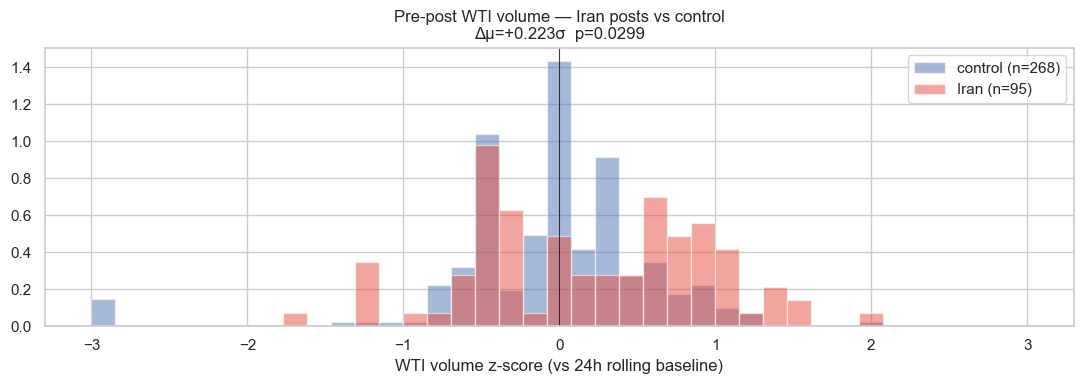

In [15]:
# Volume anomaly: WTI handelsvolume in het post-uur vs 24h baseline
# Als hypothese ondersteund: Iran posts vallen systematisch in uren met verhoogd volume

wti_hour = hourly[hourly["ticker"] == "WTI"].set_index("datetime").sort_index().copy()
wti_hour["log_vol"] = np.log(wti_hour["volume"].clip(lower=1))
wti_hour["log_vol_base"] = wti_hour["log_vol"].rolling(24, min_periods=12).mean()
wti_hour["log_vol_std"] = wti_hour["log_vol"].rolling(24, min_periods=12).std()
wti_hour["vol_zscore"] = (wti_hour["log_vol"] - wti_hour["log_vol_base"]) / wti_hour["log_vol_std"]


def get_vol_zscore_at(post_ts):
    target = post_ts.floor("1h")
    if target in wti_hour.index:
        return wti_hour.at[target, "vol_zscore"]
    return np.nan


iran_in_h = iran_posts[iran_posts["timestamp_utc"] >= wti_hour.index.min()]
control_pool = control_posts[control_posts["timestamp_utc"] >= wti_hour.index.min()]
control_in_h = control_pool.sample(min(500, len(control_pool)), random_state=42)

iran_z = iran_in_h["timestamp_utc"].apply(get_vol_zscore_at).dropna()
control_z = control_in_h["timestamp_utc"].apply(get_vol_zscore_at).dropna()

print("=== Volume z-score in post-uur (vs 24h rolling baseline) ===")
print(f"Iran posts  (n={len(iran_z):>3}): mean z = {iran_z.mean():+.3f}  median = {iran_z.median():+.3f}")
print(f"Control     (n={len(control_z):>3}): mean z = {control_z.mean():+.3f}  median = {control_z.median():+.3f}")
t, p = stats.ttest_ind(iran_z, control_z, equal_var=False)
print(f"\nt-test:  t={t:.3f}  p={p:.4f}")
print("\nInterpretatie:")
print("  Δμ > 0 én p<0.05  → volume systematisch verhoogd in Iran-post uren (consistent met informed positioning)")
print("  Δμ ~ 0            → geen anomaal volume rond posts")

# Plot
fig, ax = plt.subplots(figsize=(11, 4))
bins = np.linspace(-3, 3, 40)
ax.hist(control_z, bins=bins, alpha=0.5, density=True, label=f"control (n={len(control_z)})")
ax.hist(iran_z, bins=bins, alpha=0.5, density=True, label=f"Iran (n={len(iran_z)})", color="#e74c3c")
ax.axvline(0, color="black", linewidth=0.5)
ax.set_xlabel("WTI volume z-score (vs 24h rolling baseline)")
ax.set_title(f"Pre-post WTI volume — Iran posts vs control\nΔμ={(iran_z.mean()-control_z.mean()):+.3f}σ  p={p:.4f}")
ax.legend()
plt.tight_layout()
plt.show()

=== Price position in 4u window vóór post ===
(0 = post valt bij lokaal dieptepunt; 1 = post valt bij lokaal hoogtepunt; 0.5 = middenin)
Iran posts (n=103): mean = 0.391  median = 0.333
Control    (n=293): mean = 0.354  median = 0.000

t-test:  t=0.803  p=0.4232

Interpretatie:
  Iran mean < 0.5 + p<0.05  → posts vallen bij dieptepunten (consistent met buy-low-then-pump)
  Iran mean ~ 0.5           → posts vallen willekeurig binnen 4u range
  Iran mean > 0.5 + p<0.05  → posts vallen bij hoogtepunten


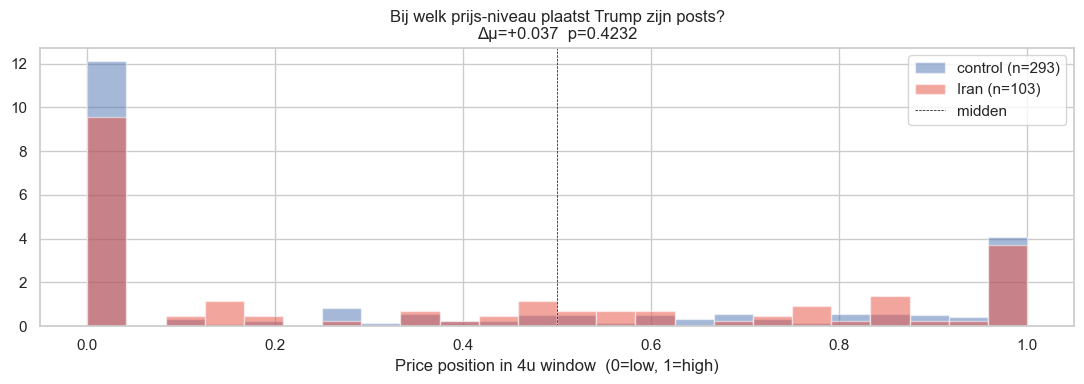

In [16]:
# Price-timing: waar staat WTI bij de post t.o.v. 4u-range?
# Manipulation-hypothese: bullish Iran posts vallen bij lokale dieptepunten (buy low, then pump)

def price_position_in_window(post_ts, window_h=4):
    pt = post_ts.floor("1h")
    window_start = pt - pd.Timedelta(hours=window_h)
    sub = wti_hour.loc[(wti_hour.index >= window_start) & (wti_hour.index <= pt)]
    if len(sub) < 3:
        return np.nan
    p_min, p_max = sub["close"].min(), sub["close"].max()
    p_at_post = sub.iloc[-1]["close"]
    return 0.5 if p_max == p_min else (p_at_post - p_min) / (p_max - p_min)


iran_pos = iran_in_h["timestamp_utc"].apply(price_position_in_window).dropna()
control_pos = control_in_h["timestamp_utc"].apply(price_position_in_window).dropna()

print("=== Price position in 4u window vóór post ===")
print("(0 = post valt bij lokaal dieptepunt; 1 = post valt bij lokaal hoogtepunt; 0.5 = middenin)")
print(f"Iran posts (n={len(iran_pos):>3}): mean = {iran_pos.mean():.3f}  median = {iran_pos.median():.3f}")
print(f"Control    (n={len(control_pos):>3}): mean = {control_pos.mean():.3f}  median = {control_pos.median():.3f}")
t, p = stats.ttest_ind(iran_pos, control_pos, equal_var=False)
print(f"\nt-test:  t={t:.3f}  p={p:.4f}")
print("\nInterpretatie:")
print("  Iran mean < 0.5 + p<0.05  → posts vallen bij dieptepunten (consistent met buy-low-then-pump)")
print("  Iran mean ~ 0.5           → posts vallen willekeurig binnen 4u range")
print("  Iran mean > 0.5 + p<0.05  → posts vallen bij hoogtepunten")

# Plot
fig, ax = plt.subplots(figsize=(11, 4))
bins = np.linspace(0, 1, 25)
ax.hist(control_pos, bins=bins, alpha=0.5, density=True, label=f"control (n={len(control_pos)})")
ax.hist(iran_pos, bins=bins, alpha=0.5, density=True, label=f"Iran (n={len(iran_pos)})", color="#e74c3c")
ax.axvline(0.5, color="black", linewidth=0.5, linestyle="--", label="midden")
ax.set_xlabel("Price position in 4u window  (0=low, 1=high)")
ax.set_title(f"Bij welk prijs-niveau plaatst Trump zijn posts?\nΔμ={(iran_pos.mean()-control_pos.mean()):+.3f}  p={p:.4f}")
ax.legend()
plt.tight_layout()
plt.show()

## 10. Bevindingen & scriptie-verhaal

**Vul aan met je echte resultaten:**

1. **Aggregaat-effect**: zien Iran-posts systematisch andere WTI-returns dan controle-posts?
   In welk window is het effect het sterkst (1h, 4h, 24h)? Statistisch significant?
2. **Robustness**: blijft het effect overeind zonder de Hormuz-cluster?
3. **Top-10 impactful posts**: welke specifieke posts veroorzaakten de grootste WTI moves?
4. **Sentiment/toxicity verschil**: zijn Iran-posts gemiddeld negatiever, toxischer?
5. **Anchor events**: wat gebeurde er rond de 5 ankermomenten?

**Voor je scriptie *Results* hoofdstuk:**

> *"Section 5.X — Iran conflict event study: We test the hypothesis that since
> the outbreak of the Iran conflict on Feb 28, 2026, Trump has used Truth Social
> posts to influence oil prices. Using intraday WTI data and a keyword-filtered
> sample of [N] Iran-related posts, we find [statistisch significante /
> niet-significante] differences from control posts (Δμ = X bp, p = Y). The
> largest individual-post impact was observed on April 11-12, 2026, when Trump's
> announcement of a naval blockade on the Strait of Hormuz coincided with a
> 9.0% WTI movement within one hour. A robustness check excluding this cluster
> yields [Δμ = X bp, p = Y]. We complement this analysis with sentiment and
> toxicity classifications, finding that Iran-related posts are [meer/minder]
> negative on average than non-Iran posts."*
